In [1]:
import os
os.chdir(r"C:\Users\cjgir\Documents\Work\Hustle")
os.getcwd()

import numpy as np
from scipy.io import loadmat    #So that we can load in MATLAB files.
from matplotlib.path import Path    #So that we can reproduce MATLAB's inpolygon function.
import matplotlib.pyplot as plt #So that we can plot any borders or points that we want to visualize.
from itertools import combinations  #So that we can generate all combinations of stops for the traveling salesman problem.
import networkx as nx    #So that we can use graph algorithms to solve the traveling salesman problem.
from scipy.sparse import lil_matrix, vstack    #So that we can create sparse matrices for the constraint setting in the traveling salesman problem.
from scipy.optimize import milp #This is our mixed integer linear program solver
from scipy.optimize import LinearConstraint #This is our constraint object which said solver needs as an argument.
from scipy.optimize import Bounds #This is our bounds object which the milp solver needs as an argument.


from Basic_functions import tsp_helpers as tsp

import matplotlib.path as pth    #So that we can reproduce MATLAB's inpolygon function.


In [2]:
#Let's generate the stops same as before
filter_size = 10
n_stops = 1000

stops = tsp.generateStops(n_stops)

[idxs, distances, Aeq] = tsp.stops_edge_idxs(stops)

In [3]:
[idxs, distances, Aeq] = tsp.filter_edges(idxs, distances, Aeq, filter_size=5)

In [5]:
open=True

In [10]:
def Solve_With_Subtour_Open(Aeq, Beq, A=None, b=None, distances=None, idxs=None, bounds_obj=None, startNode=None, endNode=None,pr='y'):
    if startNode is not None and endNode is not None:
        if startNode == endNode:
            print("You made your startNode and endNode the same! Solving the problem as a closed tour instead.")
            return tsp.solve_with_subtour_constraints(Aeq, Beq, A, b, distances, idxs, bounds_obj, pr=pr)

    #Make sure the print parameter is y or n
    if pr not in ['y', 'yg', 'n']:
        raise ValueError("print parameter must be 'y' or 'n'")

    #Make sure that the A and b objects are correct size, if they are given.
    #Only then can you safely combine them with the equality constraints.
    if A is not None:
        assert A.shape[1] == Aeq.shape[1], "A must have the same number of columns as Aeq"
        AeqA = vstack(
            [Aeq, A],
            format = "lil"
        )
    else:
        AeqA = Aeq

    #For this version, we actually need to change the lower bound for Beq to be a vector of ones; beginning and ending nodes willl have just one edge.
    BeqOnes = np.ones_like(Beq)

    if b is not None:
        assert b.shape[0] == A.shape[0], "b must have the same number of rows as A"
        #No lower bounds for the inequality constraints, so we set them to zero
        bl = np.concatenate(
            [BeqOnes, np.zeros((A.shape[0]))]
        )
        #The upper bounds are all 2's, plus the constraints of the observed subtours.
        bu = np.concatenate(
            [Beq, b]
        )
    else:
        bl = BeqOnes
        bu = Beq

    #Everything above -- minus one tweak to bl, was already present appending the inequality constraints as subtour constraints.
    #However, one tweak we made afterwards was that in this function, the subtour constraints may or may not be present. hence the "if A is not None", ditto with "if b is not None"
    #Everything below is related to making the TSP problem open.
    #First, that the total number of edges must now be one less than the number of nodes, since the tour is open.
    #Recover the number of stops (nodes)
    num_stops = Aeq.shape[0]
    #Append a row of ones to the combined equality and inequality constraint matrix to account for the open tour requirement.
    AeqA = vstack(
        [AeqA, np.ones((1, AeqA.shape[1]))],
        format="lil"
    )
    bl = np.concatenate(
        [bl, np.array([num_stops - 1])]
    )
    bu = np.concatenate(
        [bu, np.array([num_stops - 1])]
    )
    if startNode is not None:
        #Make sure that the start node is a valid number
        if not (0 <= startNode < num_stops):
            raise ValueError("startNode must be between 0 and num_stops-1")
        #Set the upper bound for the start node to 1, ensuring it is at one end of the tour
        bu[startNode] = 1

    if endNode is not None:
        #Make sure that the end node is a valid number
        if not (0 <= endNode < num_stops):
            raise ValueError("endNode must be between 0 and num_stops-1")
        #Set the upper bound for the end node to 1, ensuring it is at the other end of the tour
        bu[endNode] = 1

    #Make sure our sizes are working together okay
    assert bl.shape[0] == bu.shape[0]
    assert AeqA.shape[0] == bl.shape[0]

    #Create a linear constraint object for the combined equality and inequality constraints
    lc = LinearConstraint(AeqA, bl, bu, keep_feasible=True)

    #And cross our fingers and hand it off to the MILP solver
    optimalLessSubtours = milp(c=distances, integrality=np.ones(idxs.shape[0]), bounds=bounds_obj, constraints=lc)

    tempGSol = nx.Graph()
    tempGSol.add_edges_from(idxs[np.round(optimalLessSubtours.x, 1).astype(bool)])

    if max(dict(tempGSol.degree()).values()) > 2 and min(dict(tempGSol.degree()).values()) < 1:
        worked = False

    else:
        worked = True

    #Let's check that Ax is within the bounds specified by the linear constraint
    if pr in ['y', 'yg']:
        Ax = Aeq @ optimalLessSubtours.x
        print("Ax:", Ax)

    if max(dict(tempGSol.degree()).values()) > 2:
        worked = False

    else:
        worked = True

    #Took out the plotting of the subtours for simplicity

    subTours = list(nx.connected_components(tempGSol))

    if pr in ['y', 'yg']:
        for i, subtour in enumerate(subTours):
            print(f"Subtour {i+1}: {subtour}")

    return tempGSol, subTours, worked

In [30]:
open=True
endpoints = [1,10]
filter_size = 10


#FULL_TSP FUNCTION TO BE CHANGED FOR IF THE GIVEN OBJECTS GET FILTERED FIRST...

#Make sure that the endpoints the user gave, if they gave any, are valid.
if endpoints is not None:
    assert len(endpoints) <= 2, "Endpoints should be a list or tuple of at most two elements."
    assert all(0 <= e < stops.shape[0] for e in endpoints), "Endpoints should be valid stop indices."

if endpoints is not None:
    startNode = endpoints[0]
    endNode = endpoints[1] if len(endpoints) == 2 else None
else:
    startNode, endNode = None, None

print(f"Start Node: {startNode}, End Node: {endNode}")

n_stops = stops.shape[0]    #Get the number of stops from the shape of the stops array.

#Now we outsource the generation of the idxs, distances, and Aeq matrices to a helper function in tsp_helpers.py
[idxs, distances, Aeq] = tsp.stops_edge_idxs(stops)
#And if we want to filter the edges, we can do that here as well.
if filter_size is not None:
    assert filter_size > 0 and filter_size < n_stops and isinstance(filter_size, int), "filter_size must be a positive integer less than the number of stops."
    [idxs, distances, Aeq] = tsp.filter_edges(idxs, distances, Aeq, filter_size=filter_size)

Beq = 2*np.ones(n_stops, dtype=np.int64) #This creates a vector of 2's to help us set the constraint of edges connected per city.

#Make sure we create the lower and upper bounds object correctly to be used in the optimize problem.
lb = np.zeros(idxs.shape[0], dtype=np.int64)   #Lower bound for the decision variables, typically set to 0.
ub = np.ones(idxs.shape[0], dtype=np.int64)    #Upper bound for the decision variables, typically set to 1.

#This linear constraint should say that b <= Aeq * x <= b, which I believe is the correct way to represent equality constraints in the form of a linear constraint.
bounds_binary = np.array([lb, ub]).T
bounds_binary

lc = LinearConstraint(Aeq, Beq, Beq, keep_feasible=True)

bounds_obj = Bounds(lb, ub)

#Do we mean to solve open, or closed?
if open:
    [tempGSol, subTours, worked] = Solve_With_Subtour_Open(Aeq, Beq, A=None, b=None, distances=distances, idxs=idxs, bounds_obj=bounds_obj, startNode=startNode, endNode=endNode, pr='n')

else:
    #Solve it as is, which creates subtours.
    optimal_subtours = milp(c=distances, integrality=np.ones(idxs.shape[0]), bounds=bounds_obj, constraints=lc)
    tempGSol = nx.Graph()
    tempGSol.add_edges_from(idxs[np.round(optimal_subtours.x, 1).astype(bool)])

A = lil_matrix((0,idxs.shape[0]), dtype=np.int8) 
#This array will hold the bounds for how many of the edges from matrix A we allow, effectively restricting loops to form among those subtour groups.
b = np.array([], dtype=np.int8) 

#Our friend here will count through the rows of A and b as we make them.
rowIdx=0

num_subtours = nx.number_connected_components(tempGSol)
subTours = list(nx.connected_components(tempGSol))

    # while len(subTours)>1:    
    #     [A, b, rowIdx] = add_subtour_constraints(A, b, rowIdx, subTours, idxs)
    #     if not open:
    #         [tempGSol, subTours, worked] = solve_with_subtour_constraints(Aeq, Beq, A, b, distances, idxs, bounds_obj)
    #     else:
    #         [tempGSol, subTours, worked] = Solve_With_Subtour_Open(Aeq, Beq, A, b, distances, idxs, bounds_obj, startNode=startNode, endNode=endNode)
    # return tempGSol, worked

Start Node: 1, End Node: 10


In [32]:
[
idxs.shape[0],
A.shape[1]
]

[5811, 5811]

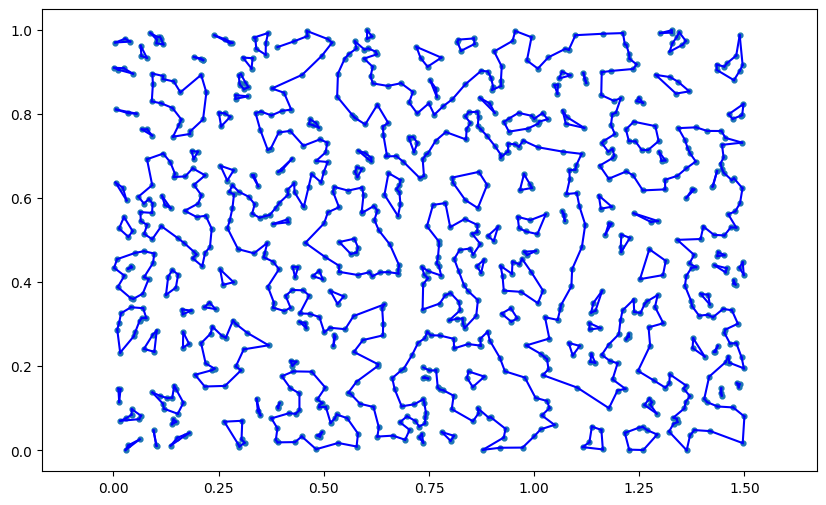

In [25]:
tsp.printGraph(stops, tempGSol)

In [ ]:
#The biggest issue now is that the function to add subtour constraints expects idxs and Aeq to have every possible edge between cities, not just the filtered ones. This means that if we have filtered edges, we need a different constraints problem.

def add_subtour_constraints(A, b, rowIdx, subTours, idxs):

    num_subtours = len(subTours)
    #Allocate the data for the new constraint on the current subtours.
    b = np.concatenate([b, np.zeros([num_subtours], dtype=np.int64)])  
    #This is scipy.sparse.vstack by the way. Not numpy.vstack. We need to set the format as "lil" 
    #because default output of coo_matrix does not support item assignment.
    A = vstack(
        [A, lil_matrix((num_subtours, idxs.shape[0]), dtype=np.int64)],
        format="lil"
    )   

    #This friend i will go through each of the current subtours we need to deal with.
    for i in range(num_subtours):

        #List all the nodes in the current subtour
        subTourIdx = list(subTours[i]) 
        #List all possible pairs of stops within the current subtour
        variations = np.array(list(combinations(range(len(subTourIdx)), 2)))   

        #This j iterates through the variations of the subtour edges.
        for j in range(len(variations)):

            #The numpy row version of the edge between the two nodes at this subtour edge variation.
            edge = np.array([subTourIdx[variations[j][0]], subTourIdx[variations[j][1]]])
            #Reorder the edge so that the smaller node comes first
            edge = np.sort(edge)

            #Where does this edge show up in the whole idxs array?
            edge_idx = np.where((idxs[:,0] == edge[0]) & (idxs[:,1] == edge[1]))[0]

            #For the subgroup associated with the given row of A, the edge_edx is among the edges we want to limit to avoid this subgroup from forming.
            A[rowIdx, edge_idx] = 1  
        #Set the corresponding bound for this subtour in b
        b[rowIdx] = len(subTourIdx) - 1

        #Move to the next row for the next subtour
        rowIdx += 1

    return A, b, rowIdx

In [ ]:
num_subtours = len(subTours)
#Allocate the data for the new constraint on the current subtours.
b = np.concatenate([b, np.zeros([num_subtours], dtype=np.int64)])  
#This is scipy.sparse.vstack by the way. Not numpy.vstack. We need to set the format as "lil" 
#because default output of coo_matrix does not support item assignment.
A = vstack(
    [A, lil_matrix((num_subtours, idxs.shape[0]), dtype=np.int64)],
    format="lil"
)   

# #This friend i will go through each of the current subtours we need to deal with.
# for i in range(num_subtours):

i=0

# #List all the nodes in the current subtour
# subTourIdx = list(subTours[i]) 
# #List all possible pairs of stops within the current subtour
# variations = np.array(list(combinations(range(len(subTourIdx)), 2)))   

# #This j iterates through the variations of the subtour edges.
# for j in range(len(variations)):

#     #The numpy row version of the edge between the two nodes at this subtour edge variation.
#     edge = np.array([subTourIdx[variations[j][0]], subTourIdx[variations[j][1]]])
#     #Reorder the edge so that the smaller node comes first
#     edge = np.sort(edge)

#     #Where does this edge show up in the whole idxs array?
#     edge_idx = np.where((idxs[:,0] == edge[0]) & (idxs[:,1] == edge[1]))[0]

#     #For the subgroup associated with the given row of A, the edge_edx is among the edges we want to limit to avoid this subgroup from forming.
#     A[rowIdx, edge_idx] = 1  
# #Set the corresponding bound for this subtour in b
# b[rowIdx] = len(subTourIdx) - 1

# #Move to the next row for the next subtour
# rowIdx += 1

In [16]:
i=2
j=0

#List all the nodes in the current subtour
subTourIdx = list(subTours[i]) 
#List all possible pairs of stops within the current subtour
variations = np.array(list(combinations(range(len(subTourIdx)), 2)))   

In [11]:
#The numpy row version of the edge between the two nodes at this subtour edge variation.
edge = np.array([subTourIdx[variations[j][0]], subTourIdx[variations[j][1]]])
#Reorder the edge so that the smaller node comes first
edge = np.sort(edge)

In [12]:
edge

array([  0, 730])

In [ ]:
#Hey look I can re-make the variations obejct to be the actual node pairs instead of just their indices within the subtour!

variations = np.sort(np.array([ [subTourIdx[variations[j][0]], subTourIdx[variations[j][1]]] for j in range(variations.shape[0])]), axis=1)

array([[  2, 513],
       [513, 515],
       [513, 521],
       ...,
       [498, 501],
       [498, 502],
       [501, 502]])

In [28]:
variations.shape[0]

3003

In [29]:
idxs.shape[0]

5774

In [ ]:
#For a given row in variations, check to see if the pair of nodes exists together in idxs
for i in variations 